<a href="https://colab.research.google.com/github/KedaarK/ML-Experiments-D17A/blob/main/Batch_A/ML5_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kernel SVM on Nonlinear Dataset

## Step 1: Generating a Nonlinear Dataset
We used **`make_circles`** from `sklearn.datasets` to create a dataset where points form two concentric circles.  
- This type of dataset is **nonlinear** and cannot be separated using a straight line.  
- It is an ideal example to show why **Kernel SVM** is useful.

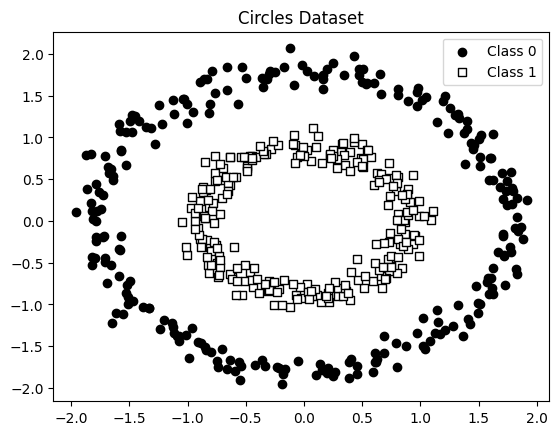

In [ ]:
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import numpy as np

# Generate circles dataset
X, y = make_circles(n_samples=500, factor=.5, noise=.05, random_state=42)

# Standardize the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Plot with black & white friendly markers
plt.scatter(X[y==0, 0], X[y==0, 1], c='black', marker='o', label="Class 0")
plt.scatter(X[y==1, 0], X[y==1, 1], c='white', edgecolors='black', marker='s', label="Class 1")

plt.title("Circles Dataset")
plt.legend()
plt.show()


# Helper functions

In [ ]:

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)
def evaluate_model(y_true, y_pred, model_name="Model"):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    # Sensitivity = Recall
    sensitivity = recall

    # Specificity = TN / (TN + FP)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp)

    # Print metrics
    print(f"\n--- {model_name} Evaluation ---")
    print(f"Accuracy     : {acc:.4f}")
    print(f"Precision    : {precision:.4f}")
    print(f"Recall       : {recall:.4f}")
    print(f"F1 Score     : {f1:.4f}")
    print(f"Sensitivity  : {sensitivity:.4f}")
    print(f"Specificity  : {specificity:.4f}")

    # Show confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

# -------------------------------
# 3. Helper Function for Decision Boundary
# -------------------------------
def plot_decision_boundary(model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors="k")
    plt.title(title)
    plt.show()


## Step 2: Training a Linear SVM

We now split the dataset into **training** and **testing sets** using `train_test_split`.
We train the model on Linear SVM and evaluate it on Accuracy, Precision, Recall F1 Score, Sensitivity, Specificity



--- Linear SVM Evaluation ---
Accuracy     : 0.4800
Precision    : 0.4634
Recall       : 0.6441
F1 Score     : 0.5390
Sensitivity  : 0.6441
Specificity  : 0.3333


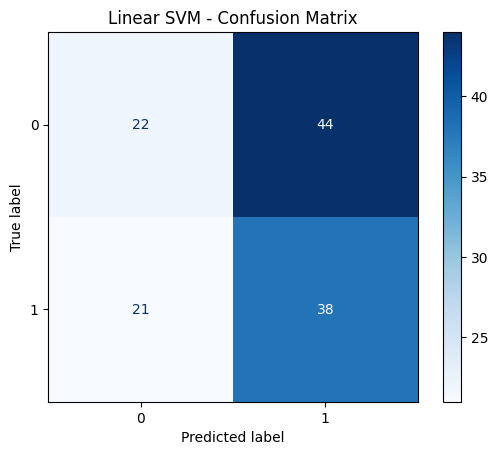

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, recall_score, f1_score)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25, random_state=0)
# Train linear SVM
classifier = SVC(kernel='linear', random_state=0)
classifier.fit(X_train, y_train)

# Predictions
y_pred = classifier.predict(X_test)
evaluate_model(y_test, y_pred, model_name="Linear SVM")

## Step 3. Using RBF Kernel SVM for Nonlinear Data

The dataset we are working with contains points forming **two concentric circles**, which is inherently nonlinear. A linear SVM fails to separate these classes because a straight line (or hyperplane) cannot divide the inner and outer circles.

To address this, we use a **Radial Basis Function (RBF) kernel** with the SVM.

- **Accuracy**: Measures the overall correctness of the model.  
- **Precision**: Indicates how many of the predicted positive cases are actually correct.  
- **Recall (Sensitivity)**: Measures how well the model identifies actual positive cases.  
- **F1 Score**: The harmonic mean of precision and recall, providing a balance between the two.  
- **Specificity**: Measures how well the model identifies actual negative cases.  

**Key Insight:**  
The RBF kernel successfully separates the concentric circles, demonstrating the power of kernel-based SVMs to handle nonlinear data. Unlike a linear SVM, which would misclassify many points, the RBF kernel adapts to the shape of the data, achieving much higher accuracy and better overall performance.



--- RBF kernel Evaluation ---
Accuracy     : 1.0000
Precision    : 1.0000
Recall       : 1.0000
F1 Score     : 1.0000
Sensitivity  : 1.0000
Specificity  : 1.0000


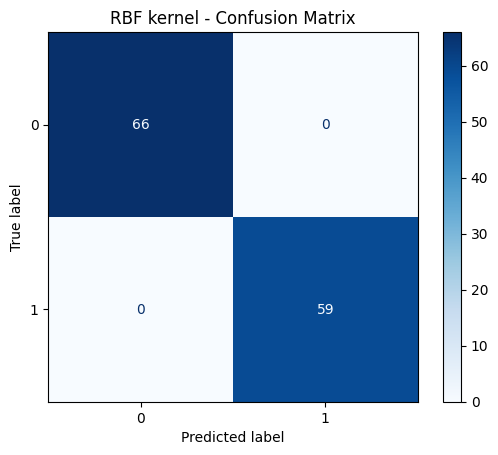

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, recall_score, f1_score)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25, random_state=0)
# Train linear SVM
classifier = SVC(kernel='rbf', random_state=0)
classifier.fit(X_train, y_train)

# Predictions
y_pred = classifier.predict(X_test)
evaluate_model(y_test, y_pred, model_name="RBF kernel")

##Step 4. Using Sigmoid Kernel SVM

In addition to linear and RBF kernels, SVM also supports the **Sigmoid kernel**, which behaves similarly to a two-layer neural network.


**Key Insight:**  
The Sigmoid kernel can handle some nonlinearities in the data, but its performance depends heavily on parameters like **gamma** and **coef0**.



--- Sigmoid kernel Evaluation ---
Accuracy     : 0.5280
Precision    : 0.5000
Recall       : 0.4915
F1 Score     : 0.4957
Sensitivity  : 0.4915
Specificity  : 0.5606


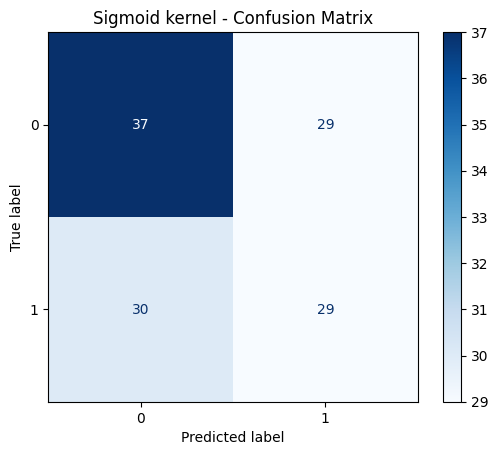

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, recall_score, f1_score)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25, random_state=0)
# Train linear SVM
classifier = SVC(kernel='sigmoid', random_state=0)
classifier.fit(X_train, y_train)

# Predictions
y_pred = classifier.predict(X_test)
evaluate_model(y_test, y_pred, model_name="Sigmoid kernel")

##Step 5. Create a meshgrid

### Subtask:
Generate a meshgrid of points to cover the feature space.


**Reasoning**:
Generate a meshgrid of points to cover the feature space based on the range of the features in X.



In [ ]:
x1 = np.arange(start = X[:, 0].min() - 1, stop = X[:, 0].max() + 1, step = 0.01)
x2 = np.arange(start = X[:, 1].min() - 1, stop = X[:, 1].max() + 1, step = 0.01)
X1, X2 = np.meshgrid(x1, x2)

## Predict on the meshgrid

### Subtask:
Use each trained SVM model to predict the class for each point in the meshgrid.


**Reasoning**:
Reshape the meshgrid and predict the classes for each point using the trained SVM models.



In [ ]:
X_grid = np.c_[X1.ravel(), X2.ravel()]
# Z_linear = classifier.predict(X_grid).reshape(X1.shape)
# Z_rbf = classifierRBF.predict(X_grid).reshape(X1.shape)
# Z_sigmoid = classifierSIG.predict(X_grid).reshape(X1.shape)

## Visualize in 3d

### Subtask:
Create a 3D scatter plot of the data points and a surface plot of the decision boundary for each model.


**Reasoning**:
Create 3D scatter plots of the data and surface plots of the decision boundaries for each kernel type (linear, RBF, sigmoid) using the generated meshgrid predictions.



# Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


# Define classifiers with different kernels


In [ ]:
X, y = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=42)

# 2. Define classifiers with different kernels
kernels = ['linear', 'rbf', 'sigmoid']
models = [SVC(kernel=k, gamma='scale').fit(X, y) for k in kernels]

# Function to plot decision boundary

In [ ]:
# 3. Function to plot decision boundary (B&W version)
def plot_decision_boundary(model, X, y, ax, title):
    h = .02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Use grayscale colormap for regions
    ax.contourf(xx, yy, Z, alpha=0.3)

    # Plot class 0 as black circles, class 1 as white squares with black edge
    ax.scatter(X[y==0, 0], X[y==0, 1], marker='o', s=20, label="Class 0")
    ax.scatter(X[y==1, 0], X[y==1, 1], facecolors='white', edgecolors='black', marker='s', s=20, label="Class 1")

    ax.set_title(title, fontsize=10)
    ax.legend(loc="upper right", fontsize=8)


# Plot all kernels with their accuracy

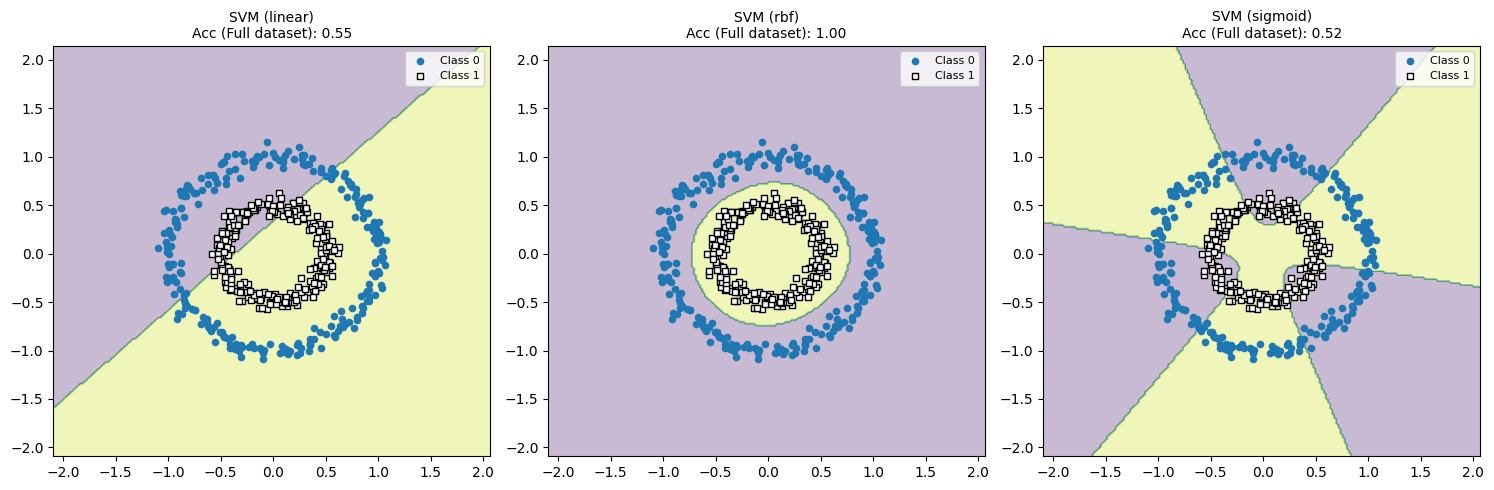

In [ ]:

# 4. Plot all kernels with their accuracy
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for model, kernel, ax in zip(models, kernels, axes):
    acc = accuracy_score(y, model.predict(X))
    plot_decision_boundary(model, X, y, ax, f"SVM ({kernel})\nAcc (Full dataset): {acc:.2f}") # Modified title

plt.tight_layout()
plt.show()

## 3D Visualization: Mapping Nonlinear Data for Linear Separation

The concentric circles dataset is **nonlinearly separable** in 2D, meaning a straight line cannot separate the inner and outer circles. To illustrate how SVM can handle nonlinear data, we perform a **nonlinear feature transformation** by adding a third dimension: the squared radius of each point, calculated as `X1^2 + X2^2`.

By mapping the data into this 3D space, the previously concentric circles become **linearly separable**. We then train a **linear SVM** on this transformed dataset.  

The 3D scatter plot shows:  
- Each point colored by its class.  
- In this new feature space, a **linear hyperplane** can separate the classes perfectly.  


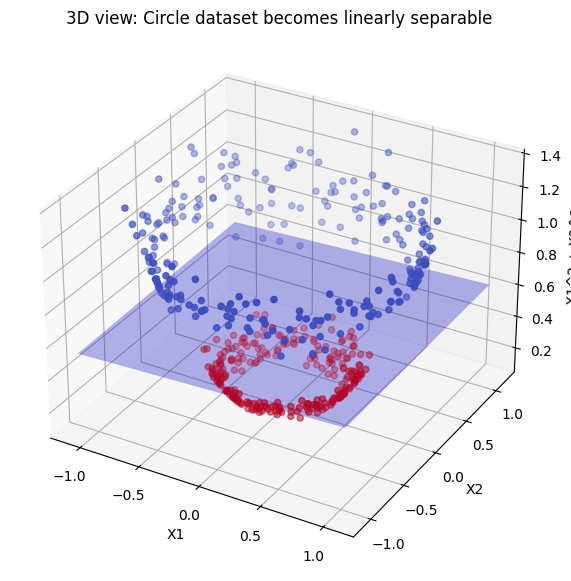

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.svm import SVC
from mpl_toolkits.mplot3d import Axes3D

# 1. Generate circle dataset
X, y = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=42)

# 2. Add a third feature: radius^2 (non-linear transformation)
X_3d = np.c_[X, X[:,0]**2 + X[:,1]**2]

# Train a linear SVM in 3D space
model_3d = SVC(kernel="linear").fit(X_3d, y)

# 3. Plot the 3D dataset with separating plane
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Scatter points
ax.scatter(X_3d[:,0], X_3d[:,1], X_3d[:,2], c=y, cmap=plt.cm.coolwarm, s=20)

# Extract plane parameters (w.x + b = 0)
w = model_3d.coef_[0]
b = model_3d.intercept_[0]

# Create a meshgrid for the plane
xx, yy = np.meshgrid(np.linspace(X_3d[:,0].min(), X_3d[:,0].max(), 50),
                     np.linspace(X_3d[:,1].min(), X_3d[:,1].max(), 50))
zz = (-w[0]*xx - w[1]*yy - b) / w[2]

# Plot the separating plane
ax.plot_surface(xx, yy, zz, alpha=0.3, color='blue')

ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("X1^2 + X2^2")
ax.set_title("3D view: Circle dataset becomes linearly separable")

plt.show()


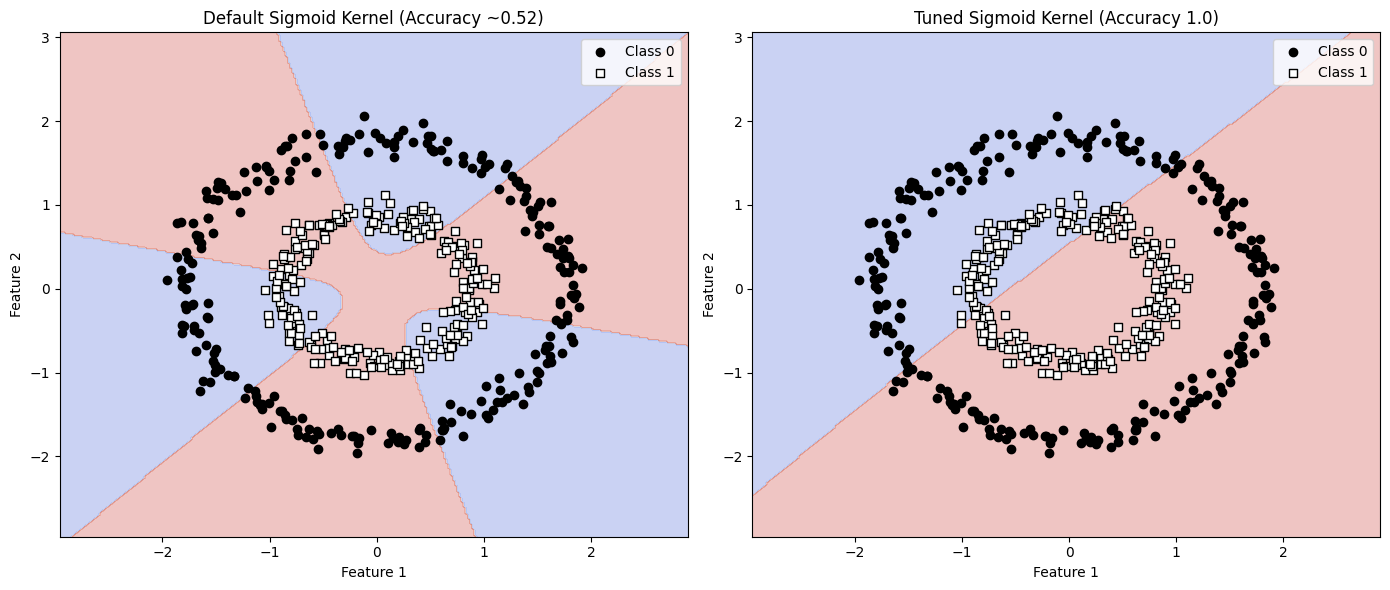

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_circles
from sklearn.preprocessing import StandardScaler

# 1. Generate and standardize the circles dataset
X_circles, y_circles = make_circles(n_samples=500, factor=.5, noise=.05, random_state=42)
scaler = StandardScaler()
X_circles = scaler.fit_transform(X_circles)

# 2. Train a sigmoid SVM model with default parameters (accuracy ~0.48)
default_sigmoid_classifier = SVC(kernel='sigmoid', random_state=0)
default_sigmoid_classifier.fit(X_circles, y_circles)

# 3. Define the best parameters for the sigmoid kernel (accuracy ~1.0)
best_sigmoid_params = {'coef0': 0, 'gamma': 0.1}

# 4. Train a sigmoid SVM model with the best parameters
tuned_sigmoid_classifier = SVC(kernel='sigmoid', **best_sigmoid_params, random_state=0)
tuned_sigmoid_classifier.fit(X_circles, y_circles)

# 5. Create a meshgrid for plotting the decision boundary
h = .02  # step size in the mesh
x_min, x_max = X_circles[:, 0].min() - 1, X_circles[:, 0].max() + 1
y_min, y_max = X_circles[:, 1].min() - 1, X_circles[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# 6. Predict on the meshgrid using both models
Z_default = default_sigmoid_classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z_default = Z_default.reshape(xx.shape)

Z_tuned = tuned_sigmoid_classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z_tuned = Z_tuned.reshape(xx.shape)

# 7. Plot the decision boundaries side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for the default sigmoid kernel
axes[0].contourf(xx, yy, Z_default, alpha=0.3, cmap=plt.cm.coolwarm)
axes[0].scatter(X_circles[y_circles==0, 0], X_circles[y_circles==0, 1], c='black', marker='o', label="Class 0")
axes[0].scatter(X_circles[y_circles==1, 0], X_circles[y_circles==1, 1], c='white', edgecolors='black', marker='s', label="Class 1")
axes[0].set_title("Default Sigmoid Kernel (Accuracy ~0.52)")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[0].legend()

# Plot for the tuned sigmoid kernel
axes[1].contourf(xx, yy, Z_tuned, alpha=0.3, cmap=plt.cm.coolwarm)
axes[1].scatter(X_circles[y_circles==0, 0], X_circles[y_circles==0, 1], c='black', marker='o', label="Class 0")
axes[1].scatter(X_circles[y_circles==1, 0], X_circles[y_circles==1, 1], c='white', edgecolors='black', marker='s', label="Class 1")
axes[1].set_title("Tuned Sigmoid Kernel (Accuracy 1.0)") # Explicitly mentioning 1.0 accuracy
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 1: Load and Prepare the Iris Dataset

- The Iris dataset contains **150 samples** of flowers, with **4 features** each and 3 classes.
- We split the data into **training (70%)** and **testing (30%)** sets.
- Features are scaled using **StandardScaler** to ensure equal weighting for the SVM model.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the Iris dataset
data = datasets.load_iris()
X, y = data.data, data.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## Step 2: Dimensionality Reduction

- To visualize the decision boundaries, we reduce the 4-dimensional data to **2 dimensions** using **PCA**.
- PCA captures the **maximum variance** in the data while reducing dimensionality, allowing us to plot the decision regions.


In [ ]:
from sklearn.decomposition import PCA

# Reduce to 2D for visualization using PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)


## Step 3: Train SVM Models with Different Kernels

- We train SVM classifiers using **linear**, **RBF**, and **sigmoid** kernels.
- Decision boundaries are plotted on the 2D PCA-transformed data.
- **Linear kernel**: Straight-line boundaries separating classes.
- **RBF kernel**: Nonlinear boundaries adapting to complex patterns.
- **Sigmoid kernel**: Can mimic a two-layer neural network for separation.


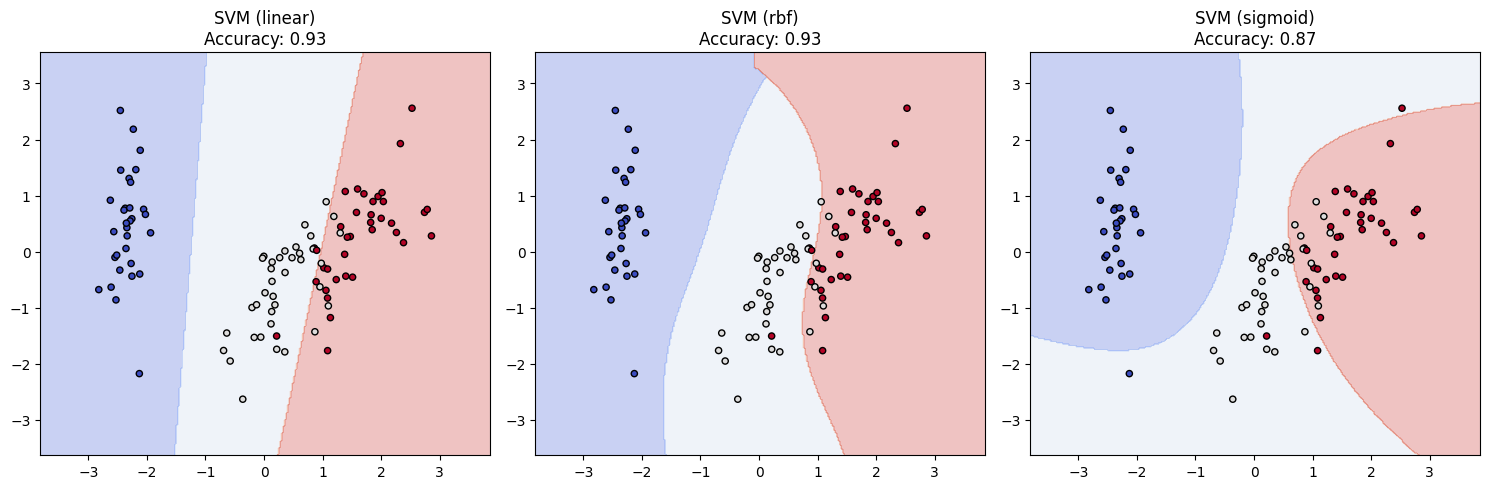

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Train SVM models with different kernels
kernels = ['linear', 'rbf', 'sigmoid']
results = {}

plt.figure(figsize=(15, 5))

for i, k in enumerate(kernels, 1):
    model = SVC(kernel=k, gamma='scale', random_state=42)
    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)
    results[k] = accuracy_score(y_test, y_pred)

    # Plot decision boundary
    x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
    y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.subplot(1, 3, i)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
    plt.title(f"SVM ({k})\nAccuracy: {results[k]:.2f}")

plt.tight_layout()
plt.show()


## Model Evaluation

- The table of accuracies shows how each kernel performs on the Iris dataset.
- Observations:
  - **Linear kernel** works well when data is nearly linearly separable.
  - **RBF kernel** adapts to complex patterns and may improve accuracy.
  - **Sigmoid kernel** performance depends on parameter tuning.
- This illustrates the importance of choosing the right kernel for your SVM model.


In [ ]:
# Print accuracies
for k, acc in results.items():
    print(f"SVM with {k} kernel -> Accuracy: {acc:.4f}")


SVM with linear kernel -> Accuracy: 0.9333
SVM with rbf kernel -> Accuracy: 0.9333
SVM with sigmoid kernel -> Accuracy: 0.8667
